In [1]:
!pip install -q -U transformers accelerate datasets

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 30.2 MB/s eta 0:00:00
device: cuda


In [2]:
MODEL_NAME = "gpt2-large"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
model.eval()

for p in model.parameters():
    p.requires_grad_(False)  # frozen model

print(model.config.n_layer, "layers,", model.config.n_embd, "hidden dim")

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.25G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

36 layers, 1280 hidden dim


In [3]:
ln_f = model.transformer.ln_f
lm_head = model.lm_head

In [4]:
from datasets import load_dataset

raw = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
text = "\n\n".join(t for t in raw["text"] if t.strip())

BLOCK_SIZE = 64
all_ids = tokenizer(text, return_tensors="pt")["input_ids"][0]
n_blocks = len(all_ids) // BLOCK_SIZE
all_ids = all_ids[: n_blocks * BLOCK_SIZE].reshape(n_blocks, BLOCK_SIZE)

dataset = TensorDataset(all_ids)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)
print(n_blocks, "training blocks of", BLOCK_SIZE, "tokens each")

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (2415650 > 1024). Running this sequence through the model will result in indexing errors


37744 training blocks of 64 tokens each


In [5]:
class TunedLensTranslators(nn.Module):
    def __init__(self, n_layer, hidden_dim):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layer)])
        for layer in self.layers:
            layer.weight.data.copy_(torch.eye(hidden_dim))
            layer.bias.data.zero_()


translators = TunedLensTranslators(model.config.n_layer, model.config.n_embd).to(device)
print(sum(p.numel() for p in translators.parameters()), "trainable parameters")

59028480 trainable parameters


In [6]:
sample_prompt = "The Eiffel Tower is located in the city of"
sample_inputs = tokenizer(sample_prompt, return_tensors="pt").to(device)
with torch.no_grad():
    sample_outputs = model(**sample_inputs, output_hidden_states=True)

check_layer = 3
h = sample_outputs.hidden_states[check_layer][0, -1, :]

plain_logits = lm_head(ln_f(h))
translated_logits = lm_head(ln_f(translators.layers[check_layer](h)))

diff = (plain_logits - translated_logits).abs().max().item()
print("identity-init check, max diff:", diff)
assert diff < 1e-4, "Untrained translator doesn't match plain logit lens -- check identity init."

identity-init check, max diff: 0.0


In [7]:
def translator_loss(translator, h, target_probs, ln_f, lm_head):
    """KL(target_probs || translated distribution) -- how far the lens's guess is
    from what the model would actually say, not from the ground-truth next token.
    """
    translated_logits = lm_head(ln_f(translator(h)))
    translated_log_probs = F.log_softmax(translated_logits.float(), dim=-1)
    return F.kl_div(translated_log_probs, target_probs, reduction="batchmean")

step 0: total loss 134.9185
step 50: total loss 46.6193
step 100: total loss 42.4539
step 150: total loss 41.7468
step 200: total loss 41.1469
step 250: total loss 41.4522


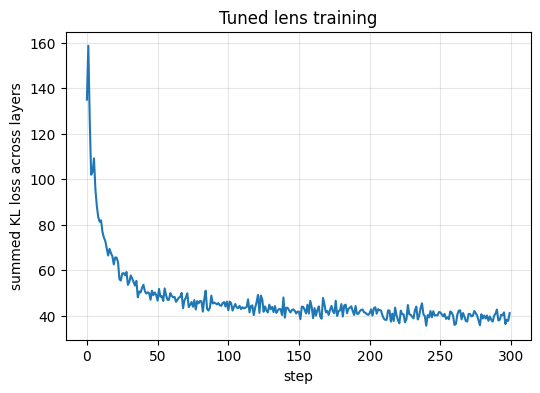

In [8]:
optimizer = torch.optim.Adam(translators.parameters(), lr=1e-3)
NUM_STEPS = 300

loss_curve = []
step = 0
for (input_ids,) in dataloader:
    if step >= NUM_STEPS:
        break
    input_ids = input_ids.to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, output_hidden_states=True)
        target_probs = F.softmax(outputs.logits.float(), dim=-1).reshape(-1, outputs.logits.shape[-1])

    optimizer.zero_grad()
    total_loss = 0.0
    for i in range(model.config.n_layer):
        h = outputs.hidden_states[i].reshape(-1, outputs.hidden_states[i].shape[-1])
        total_loss = total_loss + translator_loss(translators.layers[i], h, target_probs, ln_f, lm_head)
    total_loss.backward()
    optimizer.step()

    loss_curve.append(total_loss.item())
    if step % 50 == 0:
        print(f"step {step}: total loss {total_loss.item():.4f}")
    step += 1

plt.figure(figsize=(6, 4))
plt.plot(loss_curve)
plt.xlabel("step")
plt.ylabel("summed KL loss across layers")
plt.title("Tuned lens training")
plt.grid(alpha=0.3)
plt.savefig("/kaggle/working/tuned_lens_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
@torch.no_grad()
def logit_lens(hidden_states, tokenizer, ln_f, lm_head, top_k=5, position=-1):
    results = []
    n = len(hidden_states)
    for i, layer_hidden in enumerate(hidden_states):
        h = layer_hidden[0, position, :]
        if i < n - 1:
            h = ln_f(h)
        logits = lm_head(h)
        probs = torch.softmax(logits.float(), dim=-1)
        top_probs, top_ids = probs.topk(top_k)
        results.append([(tokenizer.decode([tid]), float(p)) for tid, p in zip(top_ids.tolist(), top_probs.tolist())])
    return results


@torch.no_grad()
def tuned_lens(hidden_states, tokenizer, translators, ln_f, lm_head, top_k=5, position=-1):
    results = []
    n = len(hidden_states)
    for i, layer_hidden in enumerate(hidden_states):
        h = layer_hidden[0, position, :]
        if i < n - 1:
            h = translators.layers[i](h)
            h = ln_f(h)
        logits = lm_head(h)
        probs = torch.softmax(logits.float(), dim=-1)
        top_probs, top_ids = probs.topk(top_k)
        results.append([(tokenizer.decode([tid]), float(p)) for tid, p in zip(top_ids.tolist(), top_probs.tolist())])
    return results


def print_lens(results):
    for i, layer_result in enumerate(results):
        label = "embed" if i == 0 else f"layer {i}"
        top1_tok, top1_p = layer_result[0]
        others = ", ".join(f"{t!r}:{p:.2f}" for t, p in layer_result[1:])
        print(f"{label:>9}  top1={top1_tok!r} ({top1_p:.2f})   next: {others}")


plain_results = logit_lens(sample_outputs.hidden_states, tokenizer, ln_f, lm_head, position=-1)
tuned_results = tuned_lens(sample_outputs.hidden_states, tokenizer, translators, ln_f, lm_head, position=-1)

print("=== plain logit lens ===")
print_lens(plain_results)
print("\n=== tuned lens ===")
print_lens(tuned_results)

=== plain logit lens ===
    embed  top1=' of' (1.00)   next: ' Of':0.00, ' in':0.00, ' that':0.00, ' with':0.00
  layer 1  top1=' the' (0.14)   next: ' exit':0.03, ' Pittsburgh':0.02, ' all':0.01, ' "':0.01
  layer 2  top1=' the' (0.04)   next: ' all':0.01, ' "':0.01, ' a':0.01, ' his':0.00
  layer 3  top1=' the' (0.03)   next: ' a':0.01, ' all':0.01, ' "':0.00, ' his':0.00
  layer 4  top1=' the' (0.02)   next: ' a':0.01, ' "':0.01, ' all':0.00, ' course':0.00
  layer 5  top1=' the' (0.02)   next: ' course':0.01, ' a':0.01, ' "':0.00, ' all':0.00
  layer 6  top1=' the' (0.02)   next: ' course':0.01, ' a':0.01, ' "':0.00, ' San':0.00
  layer 7  top1=' the' (0.02)   next: ' course':0.01, ' San':0.01, ' "':0.00, ' late':0.00
  layer 8  top1=' the' (0.02)   next: ' course':0.01, ' North':0.01, ' West':0.01, ' San':0.01
  layer 9  top1=' West' (0.01)   next: ' San':0.01, ' North':0.01, ' King':0.01, ' summer':0.01
 layer 10  top1=' San' (0.03)   next: ' King':0.02, ' West':0.01, ' South':0

In [10]:
def flip_count(results):
    """Number of times the top-1 token changes from one layer to the next."""
    top1_tokens = [layer_result[0][0] for layer_result in results]
    return sum(1 for a, b in zip(top1_tokens, top1_tokens[1:]) if a != b)


def top1_jaggedness(results):
    """Total variation of the top-1 probability across layers -- sum of |delta| between
    consecutive layers. Higher = more up-and-down wobble in confidence, not just direction.
    """
    top1_probs = [layer_result[0][1] for layer_result in results]
    return sum(abs(a - b) for a, b in zip(top1_probs, top1_probs[1:]))


plain_flips, tuned_flips = flip_count(plain_results), flip_count(tuned_results)
plain_jag, tuned_jag = top1_jaggedness(plain_results), top1_jaggedness(tuned_results)

print(f"plain logit lens : {plain_flips} top-1 flips, jaggedness={plain_jag:.2f}")
print(f"tuned lens       : {tuned_flips} top-1 flips, jaggedness={tuned_jag:.2f}")

plain logit lens : 7 top-1 flips, jaggedness=2.59
tuned lens       : 4 top-1 flips, jaggedness=1.65


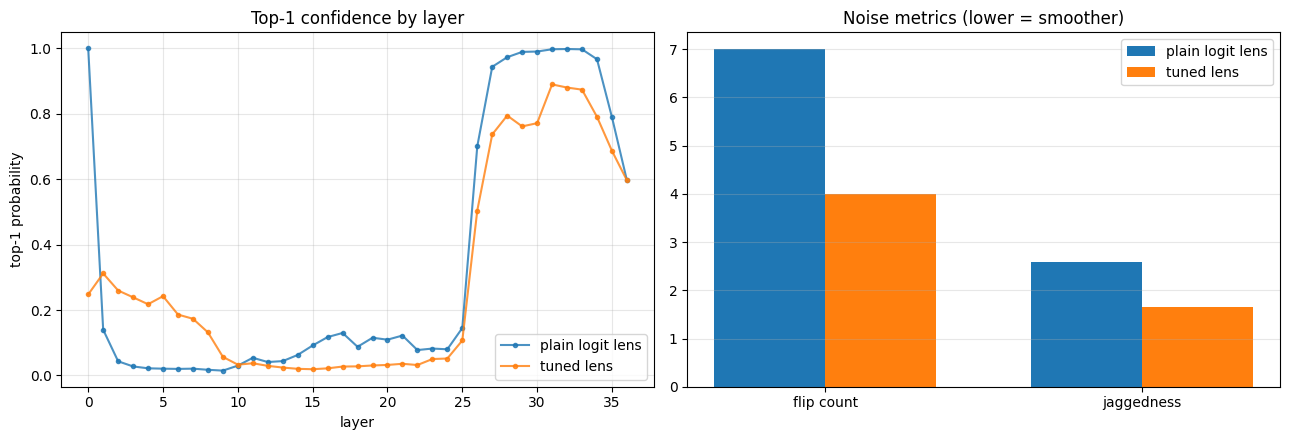

In [11]:
layers = list(range(len(plain_results)))
plain_top1_probs = [r[0][1] for r in plain_results]
tuned_top1_probs = [r[0][1] for r in tuned_results]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# confidence trajectory
axes[0].plot(layers, plain_top1_probs, marker="o", markersize=3, label="plain logit lens", alpha=0.8)
axes[0].plot(layers, tuned_top1_probs, marker="o", markersize=3, label="tuned lens", alpha=0.8)
axes[0].set_xlabel("layer")
axes[0].set_ylabel("top-1 probability")
axes[0].set_title("Top-1 confidence by layer")
axes[0].legend()
axes[0].grid(alpha=0.3)

# flip count and jaggedness
metrics = ["flip count", "jaggedness"]
plain_vals = [plain_flips, plain_jag]
tuned_vals = [tuned_flips, tuned_jag]
x = range(len(metrics))
width = 0.35

axes[1].bar([i - width / 2 for i in x], plain_vals, width, label="plain logit lens")
axes[1].bar([i + width / 2 for i in x], tuned_vals, width, label="tuned lens")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(metrics)
axes[1].set_title("Noise metrics (lower = smoother)")
axes[1].legend()
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("/kaggle/working/tuned_vs_plain_noise.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
test_prompts = {
    "factual recall": [
        "The capital of Japan is",
        "Isaac Newton is famous for the theory of",
    ],
    "induction / copying": [
        "The quick brown fox jumps over the lazy dog. The quick brown fox jumps over the lazy",
        "Alice and Bob were friends. One day, Alice and",
    ],
    "multi-hop": [
        "The author of Romeo and Juliet was born in the town of",
    ],
    "ambiguous / no ground truth": [
        "The best programming language is",
    ],
    "hallucination-prone": [
        "The capital of Australia is",
    ],
}

multi_prompt_results = {}

for category, prompts in test_prompts.items():
    for prompt in prompts:
        inputs = tokenizer(prompt, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)

        plain_r = logit_lens(outputs.hidden_states, tokenizer, ln_f, lm_head, position=-1)
        tuned_r = tuned_lens(outputs.hidden_states, tokenizer, translators, ln_f, lm_head, position=-1)

        multi_prompt_results[prompt] = {
            "category": category,
            "plain_results": plain_r,
            "tuned_results": tuned_r,
            "plain_flips": flip_count(plain_r),
            "tuned_flips": flip_count(tuned_r),
            "plain_jag": top1_jaggedness(plain_r),
            "tuned_jag": top1_jaggedness(tuned_r),
        }

        print(f"[{category}] {prompt!r}")
        print(f"  plain: {multi_prompt_results[prompt]['plain_flips']} flips, jaggedness={multi_prompt_results[prompt]['plain_jag']:.2f}, "
              f"final top1={plain_r[-1][0][0]!r} ({plain_r[-1][0][1]:.2f})")
        print(f"  tuned: {multi_prompt_results[prompt]['tuned_flips']} flips, jaggedness={multi_prompt_results[prompt]['tuned_jag']:.2f}, "
              f"final top1={tuned_r[-1][0][0]!r} ({tuned_r[-1][0][1]:.2f})")
        print()

[factual recall] 'The capital of Japan is'
  plain: 5 flips, jaggedness=2.67, final top1=' Tokyo' (0.41)
  tuned: 4 flips, jaggedness=1.93, final top1=' Tokyo' (0.41)

[factual recall] 'Isaac Newton is famous for the theory of'
  plain: 6 flips, jaggedness=2.83, final top1=' gravity' (0.27)
  tuned: 6 flips, jaggedness=2.28, final top1=' gravity' (0.27)

[induction / copying] 'The quick brown fox jumps over the lazy dog. The quick brown fox jumps over the lazy'
  plain: 2 flips, jaggedness=2.20, final top1=' dog' (0.99)
  tuned: 8 flips, jaggedness=1.30, final top1=' dog' (0.99)

[induction / copying] 'Alice and Bob were friends. One day, Alice and'
  plain: 5 flips, jaggedness=2.17, final top1=' Bob' (0.95)
  tuned: 6 flips, jaggedness=1.47, final top1=' Bob' (0.95)

[multi-hop] 'The author of Romeo and Juliet was born in the town of'
  plain: 10 flips, jaggedness=2.44, final top1=' Romeo' (0.03)
  tuned: 7 flips, jaggedness=0.54, final top1=' Romeo' (0.03)

[ambiguous / no ground tru

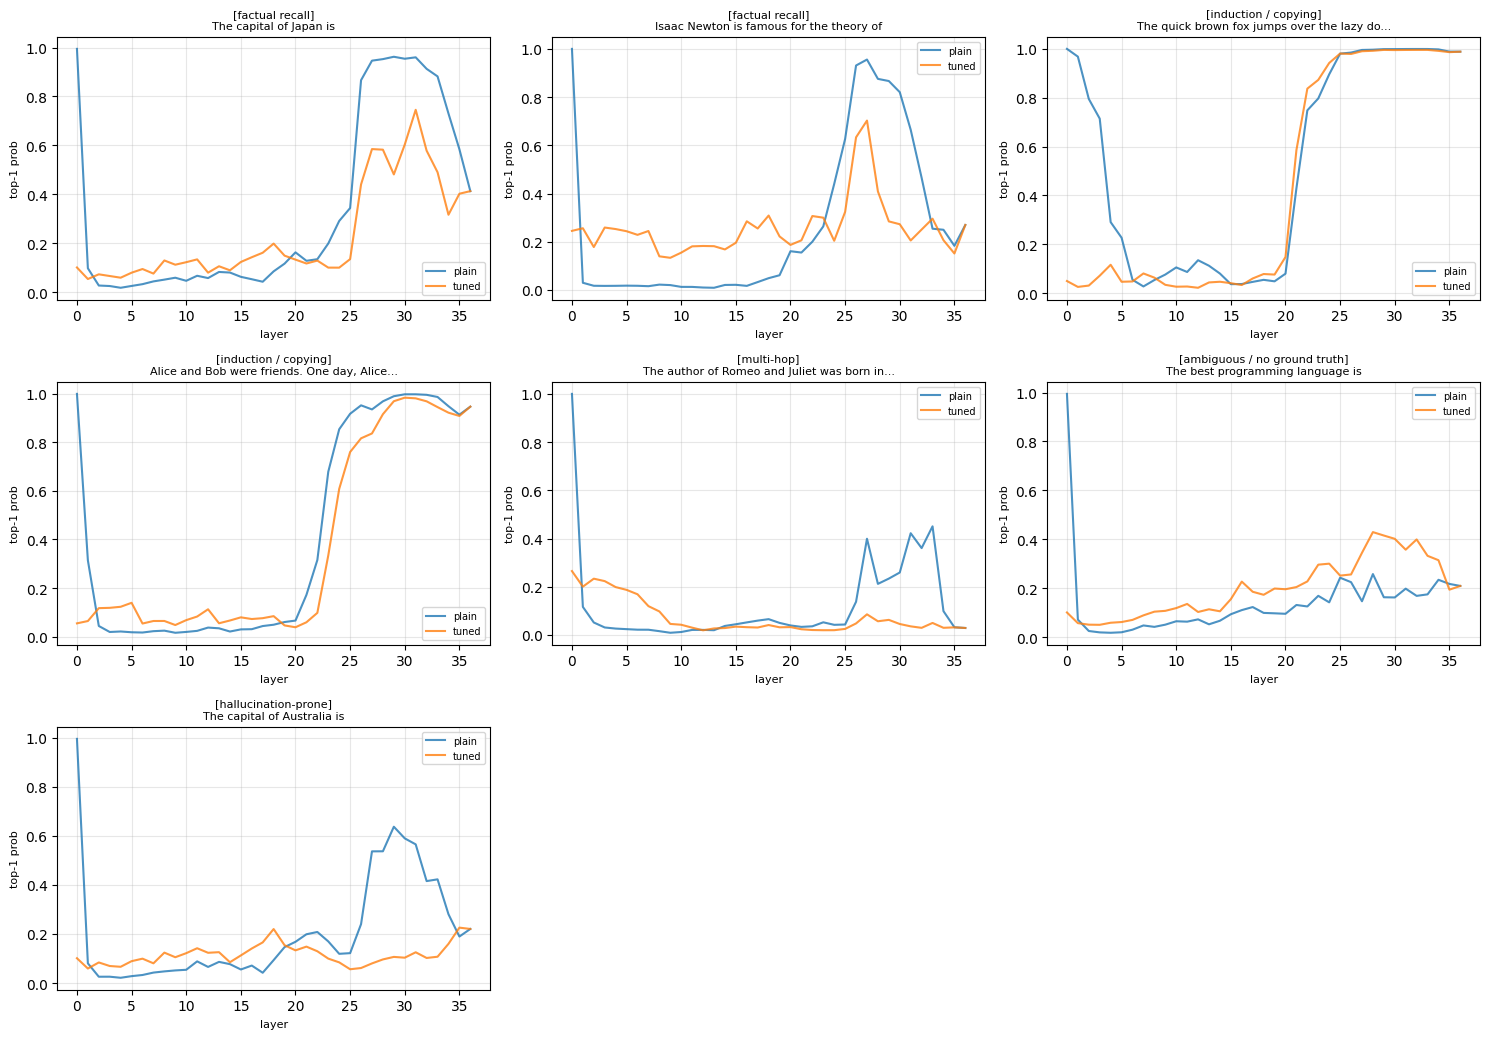

In [13]:
n = len(multi_prompt_results)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.5 * rows))
axes = axes.flatten()

for ax, (prompt, r) in zip(axes, multi_prompt_results.items()):
    layers = list(range(len(r["plain_results"])))
    plain_p = [x[0][1] for x in r["plain_results"]]
    tuned_p = [x[0][1] for x in r["tuned_results"]]
    ax.plot(layers, plain_p, label="plain", alpha=0.8)
    ax.plot(layers, tuned_p, label="tuned", alpha=0.8)
    title = prompt if len(prompt) <= 45 else prompt[:42] + "..."
    ax.set_title(f"[{r['category']}]\n{title}", fontsize=8)
    ax.set_xlabel("layer", fontsize=8)
    ax.set_ylabel("top-1 prob", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

for ax in axes[len(multi_prompt_results):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/multi_prompt_lens_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
os.makedirs("/kaggle/working/cache", exist_ok=True)

torch.save(
    {
        "model_name": MODEL_NAME,
        "n_layer": model.config.n_layer,
        "hidden_dim": model.config.n_embd,
        "translators_state_dict": translators.state_dict(),
        "loss_curve": loss_curve,
        "num_steps": NUM_STEPS,
        "block_size": BLOCK_SIZE,
        "sample_prompt": sample_prompt,
        "noise_metrics": {
            "plain_flips": plain_flips,
            "tuned_flips": tuned_flips,
            "plain_jaggedness": plain_jag,
            "tuned_jaggedness": tuned_jag,
        },
    },
    "/kaggle/working/cache/day3_tuned_lens_gpt2_large.pt",
)
print("saved.")

saved.
